# LM Domain Adaptation: DistilGPT-2 + LoRA

We fine-tune `distilgpt2` on the same toxic-comment corpus using causal language modeling.
This directly measures the trade-offs from task 2.6: adaptation speed, GPU memory, and perplexity.

Configurations: LoRA rank 4 / 8 / 16 and full fine-tuning as an upper bound.

We reuse the **same data splits** as the LoRA classifier (`data/models/transformer_lora/data_splits.pkl`)
to avoid any leakage between LM training and the classification test set.

In [23]:
import json
import math
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM, get_linear_schedule_with_warmup
from peft import get_peft_model, LoraConfig, TaskType

# walk up from cwd until we find the project root
ROOT = Path.cwd()
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "data" / "models").exists():
        ROOT = _p
        break

SPLITS_PATH = ROOT / "data" / "models" / "transformer_lora" / "data_splits.pkl"
EXP_DIR = Path("data")
IMG_DIR = ROOT / "docs" / "images"

MODEL_NAME = "distilgpt2"
MAX_LENGTH = 128
SEED = 42

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

assert SPLITS_PATH.exists(), (
    f"Splits not found at {SPLITS_PATH}. "
    "Train the LoRA classifier first:\n"
    "  python -m model.train --model transformer_lora "
    "--data data/train_dataset_clean.csv --output data/models/transformer_lora --train-subset 100000"
)

print(f"ROOT: {ROOT}")
print(f"Device: {DEVICE}")

ROOT: /Users/ar.babkin/Desktop/Visual_Studio_IDE/NLP-case-study-project
Device: mps


## 1. Data

We reuse the splits from the LoRA classifier: same train/val/test texts, labels dropped.
This ensures LM training never sees the classification test set.

In [24]:
with open(SPLITS_PATH, "rb") as f:
    splits = pickle.load(f)

train_texts = list(splits["X_train"]) # 90K (balanced)
val_texts = list(splits["X_val"]) # 10K
test_texts = list(splits["X_test"]) # 92K

# use a fixed 5K subset for perplexity evaluation — fast and representative
rng = __import__('numpy').random.RandomState(SEED)
ppl_texts = list(rng.choice(test_texts, size=5000, replace=False))

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}, PPL eval: {len(ppl_texts)}")


Train: 90000, Val: 10000, Test: 92061, PPL eval: 5000


## 2. Perplexity function

In [25]:
from tqdm.auto import tqdm

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token


def compute_perplexity(model, texts, batch_size=32):
    model.eval()
    total_nll, total_tokens = 0.0, 0
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="perplexity", leave=False):
            batch = texts[i:i + batch_size]
            enc = tokenizer(batch, return_tensors="pt", truncation=True,
                            padding=True, max_length=MAX_LENGTH)
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            labels = enc["input_ids"].clone()
            labels[labels == tokenizer.pad_token_id] = -100
            loss = model(**enc, labels=labels).loss
            n_tokens = (labels != -100).sum().item()
            total_nll += loss.item() * n_tokens
            total_tokens += n_tokens
    return math.exp(total_nll / total_tokens)


## 3. Baseline perplexity (no fine-tuning)

In [26]:
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
ppl_base = compute_perplexity(base_model, ppl_texts)
del base_model

print(f"Base PPL (no fine-tuning): {ppl_base:.2f}")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

perplexity:   0%|          | 0/157 [00:00<?, ?it/s]

Base PPL (no fine-tuning): 27.54


## 4. Training

In [27]:
class TextDataset(Dataset):
    def __init__(self, texts):
        enc = tokenizer(texts, truncation=True, padding="max_length",
                        max_length=MAX_LENGTH, return_tensors="pt")
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, i):
        labels = self.input_ids[i].clone()
        labels[labels == tokenizer.pad_token_id] = -100
        return {"input_ids": self.input_ids[i],
                "attention_mask": self.attention_mask[i],
                "labels": labels}


def run_experiment(rank, epochs=1, batch_size=16, lr=3e-4, full_ft=False):
    """Train distilgpt2 with LoRA (or full FT) and return metrics."""
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

    if not full_ft:
        lora_config = LoraConfig(
            task_type=TaskType.CAUSAL_LM,
            r=rank, lora_alpha=rank * 2, lora_dropout=0.05,
            target_modules=["c_attn"],
        )
        model = get_peft_model(model, lora_config)
        model.print_trainable_parameters()

    model.to(DEVICE)

    loader = DataLoader(TextDataset(train_texts), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=len(loader) // 10,
        num_training_steps=len(loader) * epochs,
    )

    # measure peak memory on first step before main loop
    if DEVICE == "mps":
        torch.mps.empty_cache()
    model.train()
    batch0 = next(iter(loader))
    batch0 = {k: v.to(DEVICE) for k, v in batch0.items()}
    model(**batch0).loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if DEVICE == "mps":
        peak_mem_mb = torch.mps.current_allocated_memory() / 1024 ** 2
    elif DEVICE == "cuda":
        peak_mem_mb = torch.cuda.max_memory_allocated() / 1024 ** 2
    else:
        peak_mem_mb = 0.0

    loss_log = []
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        pbar = tqdm(loader, desc=f"epoch {epoch + 1}/{epochs}")
        for step, batch in enumerate(pbar):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            loss = model(**batch).loss
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
            if step % 100 == 0:
                loss_log.append({"epoch": epoch, "step": step, "loss": loss.item()})

    train_time_min = (time.time() - t0) / 60
    ppl_after = compute_perplexity(model, ppl_texts)

    # save adapters only (not merged) to measure real checkpoint size
    name = f"lora_r{rank}" if not full_ft else "full_ft"
    save_path = EXP_DIR / name
    model.save_pretrained(save_path)
    checkpoint_mb = sum(f.stat().st_size for f in save_path.rglob("*") if f.is_file()) / 1024 ** 2

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "ppl": ppl_after,
        "train_time_min": round(train_time_min, 1),
        "peak_mem_mb": round(peak_mem_mb, 0),
        "checkpoint_mb": round(checkpoint_mb, 1),
        "trainable_params": trainable,
        "loss_log": loss_log,
    }


## 5. Sweep: LoRA r=4/8/16 + Full FT

In [28]:
RESULTS_PATH   = EXP_DIR / "results.json"
LOSS_LOGS_PATH = EXP_DIR / "loss_logs.json"

if RESULTS_PATH.exists():
    with open(RESULTS_PATH) as f:
        results = json.load(f)
    with open(LOSS_LOGS_PATH) as f:
        loss_logs = json.load(f)
    print("Loaded cached results.")
else:
    results = {}
    loss_logs = {}
    results["base"] = {"ppl": ppl_base, "train_time_min": 0,
                       "peak_mem_mb": 0, "checkpoint_mb": 0, "trainable_params": 0}

    for r in [4, 8, 16]:
        print(f"\n--- LoRA r={r} ---")
        res = run_experiment(r)
        loss_logs[f"LoRA r={r}"] = res.pop("loss_log")
        results[f"LoRA r={r}"] = res

    print("\n--- Full FT ---")
    res = run_experiment(None, lr=2e-5, full_ft=True)
    loss_logs["Full FT"] = res.pop("loss_log")
    results["Full FT"] = res

    with open(RESULTS_PATH, "w") as f:
        json.dump(results, f, indent=2)
    with open(LOSS_LOGS_PATH, "w") as f:
        json.dump(loss_logs, f, indent=2)
    print("\nResults and loss logs saved.")



--- LoRA r=4 ---


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

trainable params: 73,728 || all params: 81,986,304 || trainable%: 0.0899


epoch 1/1:   0%|          | 0/5625 [00:00<?, ?it/s]

perplexity:   0%|          | 0/157 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

epoch 1/1:   0%|          | 0/5625 [00:00<?, ?it/s]

perplexity:   0%|          | 0/157 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Results and loss logs saved.


## 6. Results table

In [29]:
rows = []
for name, r in results.items():
    ppl_delta = ppl_base - r["ppl"] if name != "base" else 0
    rows.append({
        "Config": name,
        "Trainable params": f"{r['trainable_params']:,}" if r["trainable_params"] else "—",
        "PPL (base→after)": f"{ppl_base:.1f} → {r['ppl']:.1f}" if name != "base" else f"{ppl_base:.1f}",
        "ΔPPL": f"{ppl_delta:+.1f}" if name != "base" else "—",
        "Train time (min)": r["train_time_min"] if name != "base" else "—",
        "Peak mem (MB)": r["peak_mem_mb"] if name != "base" else "—",
        "Checkpoint (MB)": r["checkpoint_mb"] if name != "base" else "—",
    })

df_results = pd.DataFrame(rows).set_index("Config")
print(df_results.to_string())

          Trainable params PPL (base→after)   ΔPPL Train time (min) Peak mem (MB) Checkpoint (MB)
Config                                                                                           
base                     —             27.5      —                —             —               —
LoRA r=4            73,728      27.5 → 21.4   +6.1             30.2         999.0             0.3
LoRA r=8           147,456      27.5 → 20.9   +6.7             32.5         988.0             0.6
LoRA r=16          294,912      27.5 → 20.1   +7.4             29.4         985.0             1.1
Full FT         81,912,576      27.5 → 17.1  +10.4             42.9        2160.0           312.5


## 7. Plots

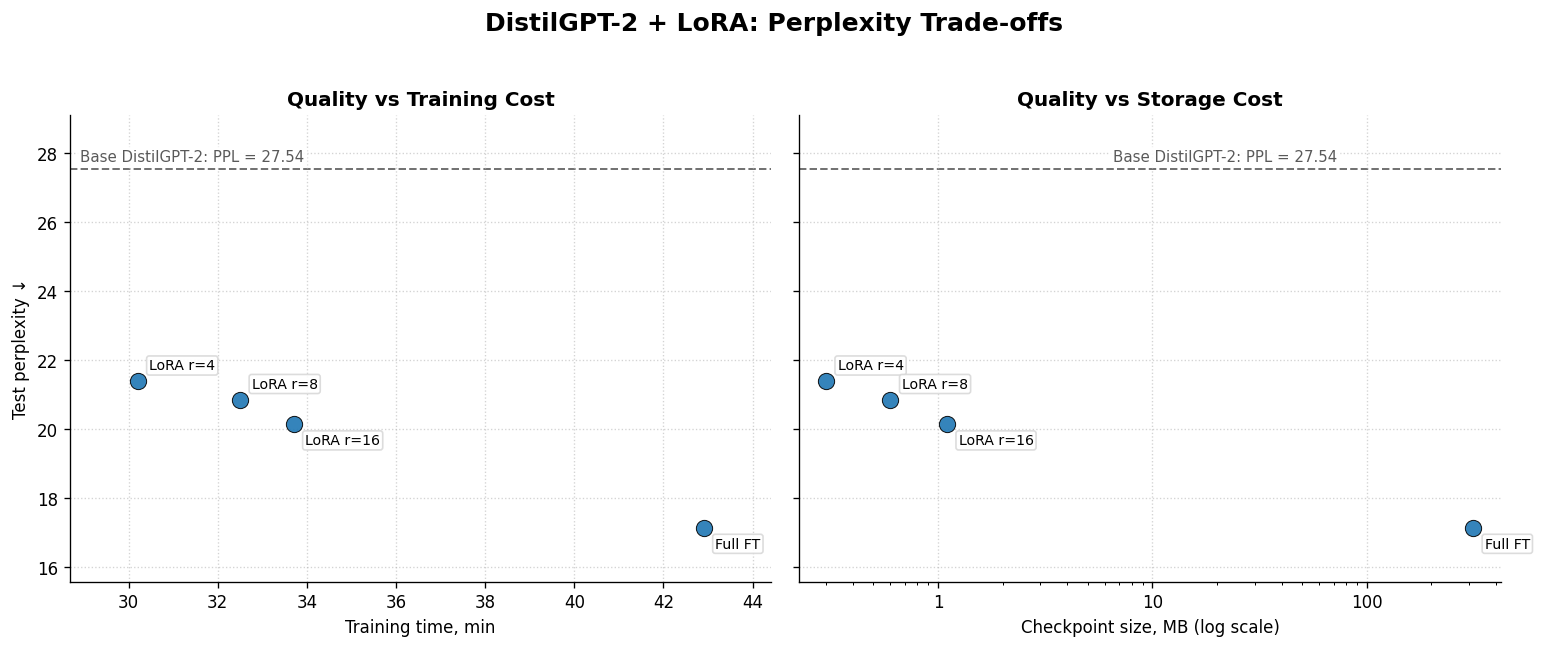

Saved to docs/images/lm_perplexity_tradeoff.png


In [45]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np

results_path = '/Users/ar.babkin/Desktop/Visual_Studio_IDE/NLP-case-study-project/model/experiments/lm_perplexity/data/results.json'
results = pd.read_json(results_path)

configs = [k for k in results if k != "base"]

ppls  = np.array([results[k]["ppl"] for k in configs], dtype=float)
times = np.array([results[k]["train_time_min"] for k in configs], dtype=float)
sizes = np.array([results[k]["checkpoint_mb"] for k in configs], dtype=float)

base_model_name = "Base DistilGPT-2"   # можешь заменить на нужное имя

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.dpi": 120,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)

def annotate_points(ax, x, y, names):
    y_med = np.median(y)
    for name, xi, yi in zip(names, x, y):
        dy = 7 if yi >= y_med else -12
        ax.annotate(
            name,
            xy=(xi, yi),
            xytext=(7, dy),
            textcoords="offset points",
            fontsize=8.5,
            bbox=dict(
                boxstyle="round,pad=0.18",
                fc="white",
                ec="0.85",
                alpha=0.9
            )
        )

def add_baseline_label(ax, text):
    # подпись у левого края baseline
    xmin, xmax = ax.get_xlim()
    x_text = xmin + 0.015 * (xmax - xmin)

    ax.text(
        x_text,
        ppl_base + 0.12,
        text,
        ha="left",
        va="bottom",
        fontsize=9,
        color="0.35",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9)
    )

def style_ax(ax, xlabel, title, logx=False):
    if logx:
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))

    ax.axhline(
        ppl_base,
        linestyle="--",
        linewidth=1.2,
        color="0.45",
        zorder=1
    )

    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight="bold")
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.55)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# --- Left: Quality vs Training Cost ---
ax = axes[0]
style_ax(ax, "Training time, min", "Quality vs Training Cost", logx=False)

ax.scatter(
    times, ppls,
    s=95,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.6,
    zorder=3
)

annotate_points(ax, times, ppls, configs)
ax.set_ylabel("Test perplexity ↓")

xpad = (times.max() - times.min()) * 0.12 if len(times) > 1 else 1
ymin = min(ppls.min(), ppl_base)
ymax = max(ppls.max(), ppl_base)
ypad = (ymax - ymin) * 0.15 if ymax > ymin else 1

ax.set_xlim(times.min() - xpad, times.max() + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

add_baseline_label(ax, f"{base_model_name}: PPL = {ppl_base:.2f}")

# --- Right: Quality vs Storage Cost ---
ax = axes[1]
style_ax(ax, "Checkpoint size, MB (log scale)", "Quality vs Storage Cost", logx=True)

ax.scatter(
    sizes, ppls,
    s=95,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.6,
    zorder=3
)

annotate_points(ax, sizes, ppls, configs)

ax.set_xlim(sizes.min() * 0.75, sizes.max() * 1.35)
ax.set_ylim(ymin - ypad, ymax + ypad)

add_baseline_label(ax, f"{base_model_name}: PPL = {ppl_base:.2f}")

fig.suptitle(
    "DistilGPT-2 + LoRA: Perplexity Trade-offs",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.savefig(IMG_DIR / "lm_perplexity_tradeoff.png", dpi=180, bbox_inches="tight")
plt.show()

print("Saved to docs/images/lm_perplexity_tradeoff.png")

## 8. Interpretation

Higher LoRA rank reduces perplexity (better domain adaptation) but increases training memory and checkpoint size.
Full fine-tuning gives the best perplexity but erases the memory and storage advantage that makes LoRA useful.

The checkpoint size difference is the clearest win for LoRA: adapters are a fraction of the full model size,
which matters when deploying multiple domain-specific versions of the same base model.

These results directly support the classification findings: LoRA is a reasonable choice when training resources
are limited, but it pays a consistent quality cost compared to full fine-tuning.